In [226]:
# Package imports

import torch
import vizdoom
import vizdoom
from vizdoom import gymnasium_wrapper
import gymnasium
import yaml

In [227]:
# Sys level imports

import sys
sys.path.append('.')
from scripts.env_setup import collect_rollouts, batch_frames
from models.vae import VAE
from models.mdnrnn import MDNRNN

Environment and config

In [228]:
with open("config.yaml", "r") as f:
    CONFIG = yaml.safe_load(f)

# Vizdoom env variables
VIZDOOM_CONFIG = CONFIG["vizdoom-env"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VAE_TRAINING_PARAMS = CONFIG["vae"]["training-params"]
VAE_MODEL_LOC = CONFIG["vae"]["model-path"]

MDNRNN_TRAINING_PARAMS = CONFIG["mdnrnn"]["training-params"]
MDNRNN_MODEL_LOC = CONFIG["mdnrnn"]["model-path"]

In [229]:
env = gymnasium.make(VIZDOOM_CONFIG, screen_resolution=vizdoom.ScreenResolution.RES_200X125)
frames, actions, game_states, rewards, done_list = collect_rollouts(env=env, episodes=1)

Rolling out Episode: 1/1: 100%|██████████| 1/1 [00:00<00:00,  1.71it/s]


In [230]:
import matplotlib.pyplot as plt

game = game_states[0][0]
action = actions[0][0]
print("Game state:", game)
print("Action variable:", action)

Game state: [ 79. 100.]
Action variable: tensor([0, 1, 0, 0])


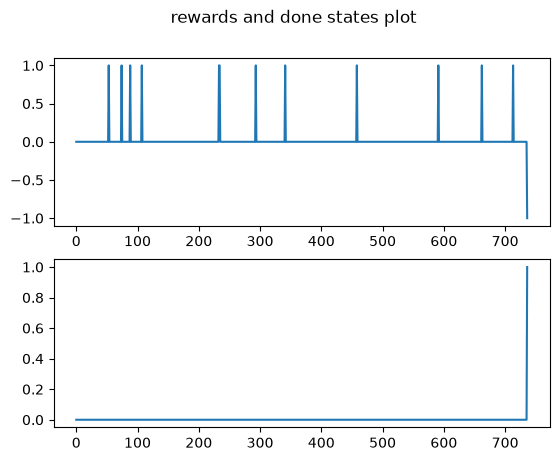

In [231]:
fig, ax = plt.subplots(2)
fig.suptitle('rewards and done states plot')
ax[0].plot(rewards[0])
ax[1].plot(done_list[0])

VAE -> Testing the VAE

In [232]:
vae = VAE(CONFIG["latent-dim"]).to(DEVICE)
vae_dict = torch.load(VAE_MODEL_LOC)
vae.load_state_dict(vae_dict)
vae.eval()

batch_frames = batch_frames(frames, batch_size=1)
frame = next(iter(batch_frames))
x_hat, z, _, _  = vae(frame.to(DEVICE))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05073643..1.0000002].


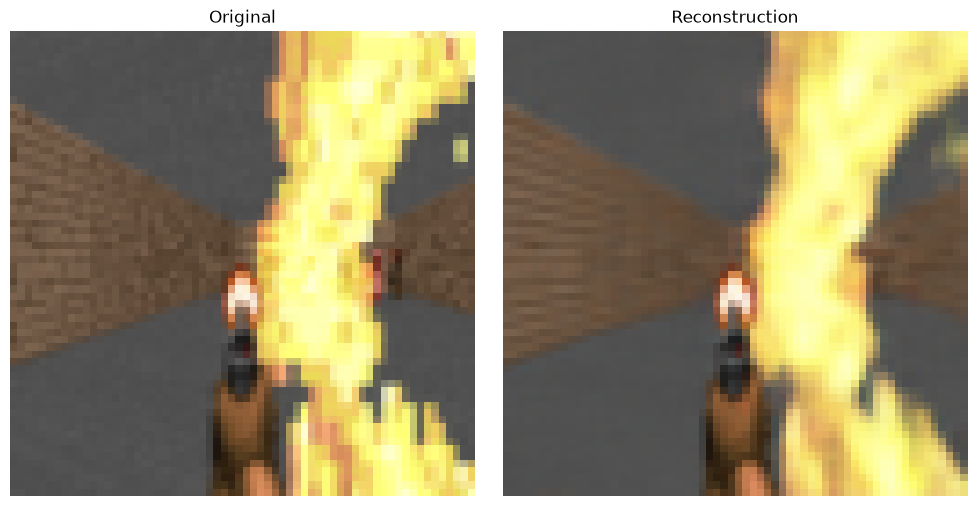

In [233]:
recon = torch.sigmoid(x_hat[0]).detach().cpu().permute(1, 2, 0)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(frame[0].permute(1, 2, 0))
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(recon)
ax[1].set_title("Reconstruction")
ax[1].axis("off")

plt.tight_layout()
plt.show()

MDNRNN evaluation 

In [234]:
frame = frames[0][0].unsqueeze(0).to(DEVICE)
print(frame.shape)
x_hat, z, _, _ = vae(frame)

torch.Size([1, 3, 64, 64])


In [235]:
from models.mdnrnn import MDNRNN

mdnrnn = MDNRNN(
        latent_dim=CONFIG["latent-dim"],
        hidden_dim=MDNRNN_TRAINING_PARAMS["hidden-dim"],
        action_dim=CONFIG["action-dim"],
        game_state_dim=CONFIG["game-state-dim"],
        mixtures=MDNRNN_TRAINING_PARAMS["mixtures"]
        ).to(DEVICE)

mdnrnn_dict = torch.load(MDNRNN_MODEL_LOC)
mdnrnn.load_state_dict(state_dict=mdnrnn_dict)
mdnrnn.eval()

MDNRNN(
  (rnn): LSTM(134, 32)
  (mdn): Linear(in_features=32, out_features=1285, bias=True)
  (reward_head): Linear(in_features=32, out_features=1, bias=True)
  (done_head): Linear(in_features=32, out_features=1, bias=True)
)

In [236]:
action = torch.as_tensor(actions[0][0]).unsqueeze(0).to(DEVICE)
game_state = torch.as_tensor(game_states[0][0]).unsqueeze(0).to(DEVICE)

h = torch.zeros(1, 1, mdnrnn.hidden_dim, device=DEVICE)
c = torch.zeros(1, 1, mdnrnn.hidden_dim, device=DEVICE)

z = z.unsqueeze(0)
action = action.unsqueeze(0)
game_state = game_state.unsqueeze(0)

print(z.shape)
print(action.shape)
print(game_state.shape)

gmm, h, c, r, d = mdnrnn(
    z=z, a=action, g=game_state, h=h, c=c
)

torch.Size([1, 1, 128])
torch.Size([1, 1, 4])
torch.Size([1, 1, 2])


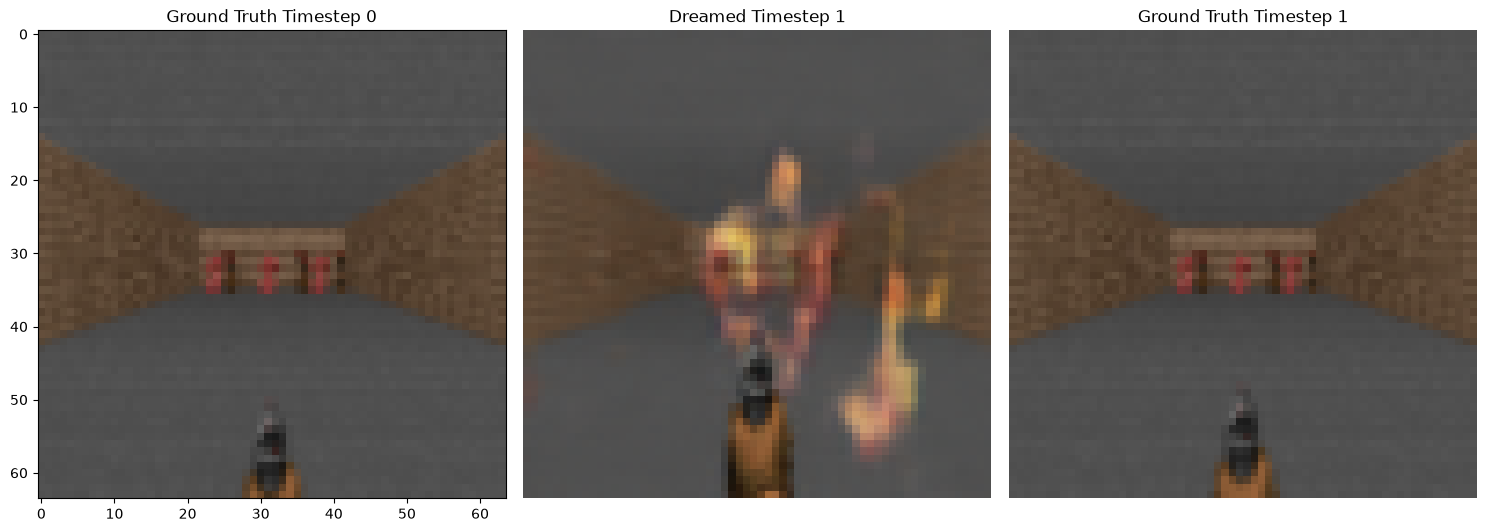

In [237]:
z_next = gmm.sample()
z_next = vae.restructure(z_next)
z_next = z_next.view(-1, 128, 8, 8)
out = vae.decoder(z_next)
out = torch.sigmoid(out[0]).cpu().detach().permute(1,2,0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(frames[0][0].permute(1, 2, 0))
ax[0].set_title("Ground Truth Timestep 0")
ax[1].axis("off")

ax[1].imshow(out)
ax[1].set_title("Dreamed Timestep 1")
ax[1].axis("off")

ax[2].imshow(frames[0][1].permute(1, 2, 0))
ax[2].set_title("Ground Truth Timestep 1")
ax[2].axis("off")

plt.tight_layout()
plt.show()